# Exhaustive Depth-First Search

This notebook contains the full N-Queens implementation for **Exhaustive Depth-First Search**.

It does all of the following when you run the main code cell:

- solves the required cases `N = 10, 30, 50, 100, 200, 500`
- prints a structured console table
- saves results in CSV format only
- saves a board SVG visual for the small solved case
- saves a performance graph image
- updates the combined comparison CSV and comparison chart


Solving the N-Queens Problem with Exhaustive Search and Genetic Algorithms
Algorithm: Exhaustive Depth-First Search
Testing board sizes: [10, 30, 50, 100, 200, 500]
Time limit per case: 15 seconds

+-----+---------+---------+-----------+------------+-------------+--------------------------------------------+
| N   | Status  | Steps   | Conflicts | Time (sec) | Memory (MB) | Note                                       |
+-----+---------+---------+-----------+------------+-------------+--------------------------------------------+
| 10  | SOLVED  | 103     | 0         | 0.000250   | 3.145479    | Solved with full exhaustive backtracking.  |
| 30  | TIMEOUT | 2998182 | N/A       | 15.000047  | 0.005930    | Stopped after reaching the 15s time limit. |
| 50  | TIMEOUT | 1077404 | N/A       | 15.000083  | 0.007133    | Stopped after reaching the 15s time limit. |
| 100 | TIMEOUT | 948935  | N/A       | 15.000125  | 0.013939    | Stopped after reaching the 15s time limit. |
| 200 | TIMEOUT | 

### Saved Board Visual

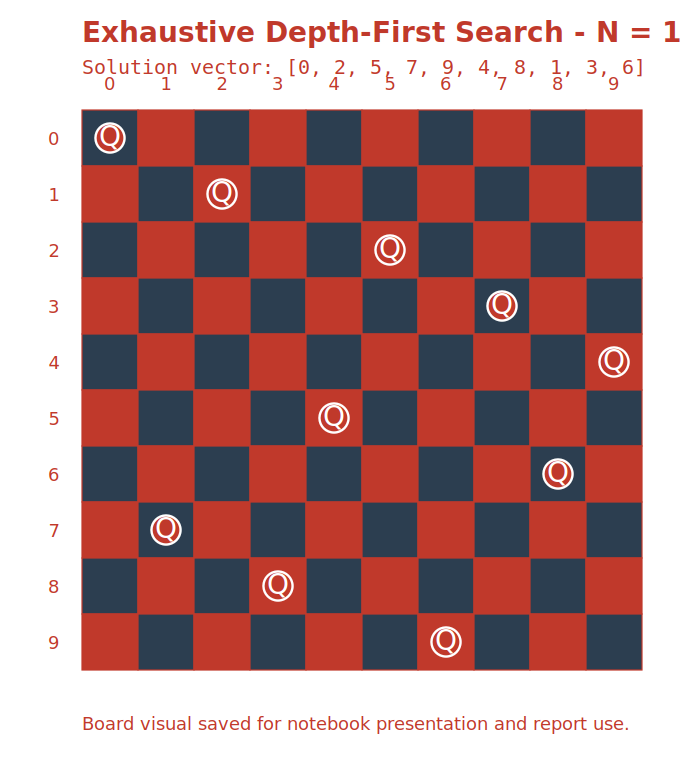

### Saved Performance Chart

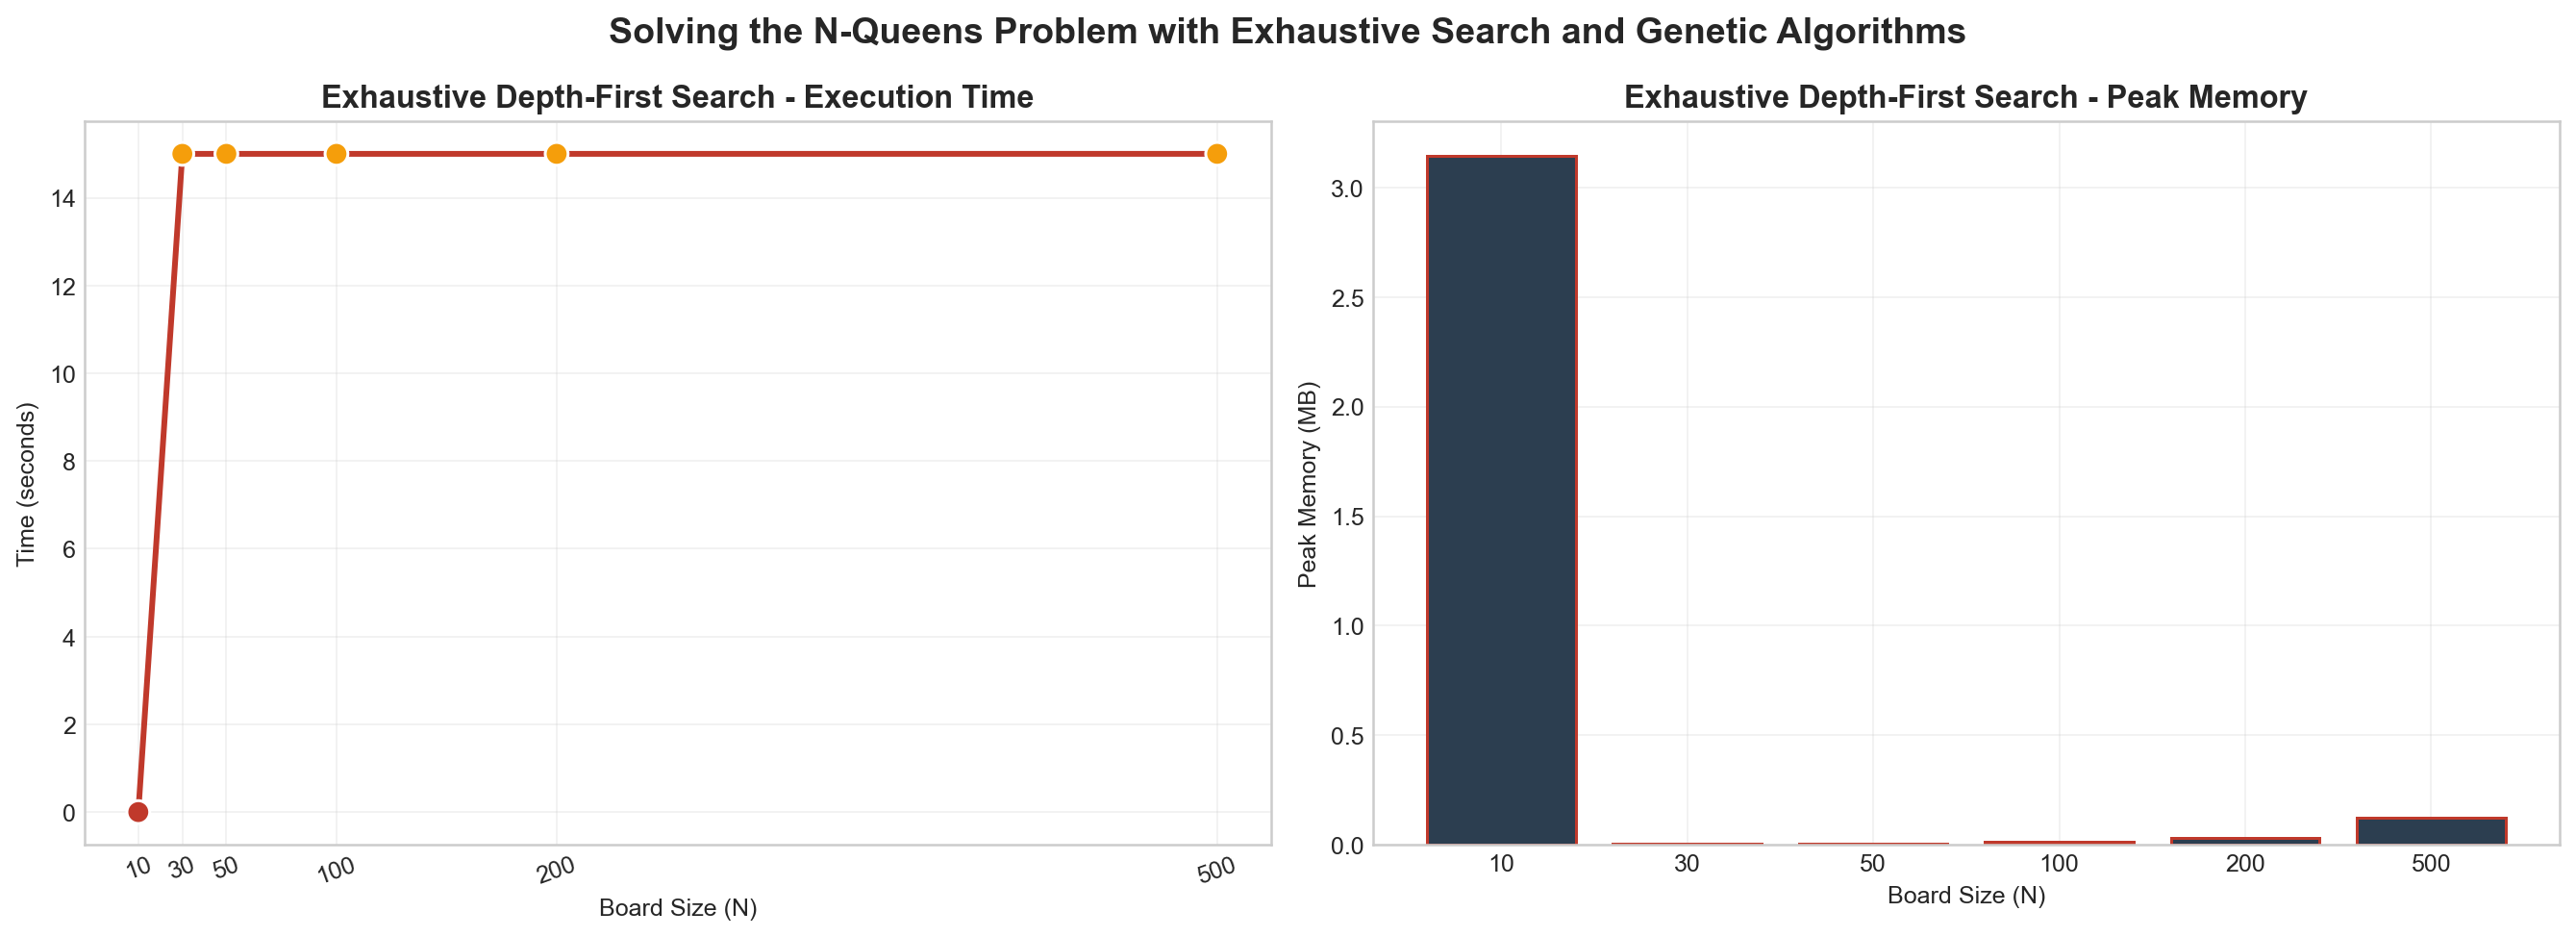

Saved CSV results to: outputs\dfs_nqueens_results.csv
Saved performance chart to: outputs\charts\dfs_nqueens_performance.png
Saved combined comparison CSV to: outputs\all_algorithms_comparison.csv
Saved combined comparison chart to: outputs\charts\all_algorithms_comparison.png


In [2]:
"""
Project Title: Solving the N-Queens Problem with Exhaustive Search and Genetic Algorithms

File: dfs_nqueens.py
Approach: Exhaustive Depth-First Search with backtracking

Design Notes
- This script uses recursive depth-first search with bitmask-based pruning.
- One queen is placed per row, so the search only tracks blocked columns and diagonals.
- A time limit is used for large N because exhaustive search becomes computationally expensive.
- For each required N value, the script records execution time, peak memory, conflicts, and status.
- Results are printed in a structured table and saved automatically after execution.
"""

from __future__ import annotations

import csv
import sys
import time
import tracemalloc
from dataclasses import dataclass
from html import escape
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown, SVG


PROJECT_TITLE = "Solving the N-Queens Problem with Exhaustive Search and Genetic Algorithms"
ALGORITHM_NAME = "Exhaustive Depth-First Search"
FILE_STEM = "dfs_nqueens"
TEST_SIZES = [10, 30, 50, 100, 200, 500]
BOARD_VISUAL_LIMIT = 12
TIME_LIMIT_SECONDS = 15.0


@dataclass
class RunResult:
    n: int
    status: str
    solved: bool
    steps: int
    conflicts: int | str
    time_seconds: float
    memory_mb: float
    note: str
    solution: list[int] | None = None
    image_path: str = "N/A"
    image_path: str = "N/A"


def count_conflicts(board: list[int]) -> int:
    column_counts: dict[int, int] = {}
    diag_main_counts: dict[int, int] = {}
    diag_anti_counts: dict[int, int] = {}

    for row, col in enumerate(board):
        column_counts[col] = column_counts.get(col, 0) + 1
        main_diag = row - col
        anti_diag = row + col
        diag_main_counts[main_diag] = diag_main_counts.get(main_diag, 0) + 1
        diag_anti_counts[anti_diag] = diag_anti_counts.get(anti_diag, 0) + 1

    return pair_conflicts(column_counts.values()) + pair_conflicts(diag_main_counts.values()) + pair_conflicts(diag_anti_counts.values())


def pair_conflicts(counts) -> int:
    total = 0
    for count in counts:
        if count > 1:
            total += count * (count - 1) // 2
    return total


def render_board(board: list[int] | None) -> str:
    if board is None:
        return "No solution board available."

    n = len(board)
    if n > BOARD_VISUAL_LIMIT:
        return f"Board visual skipped for N = {n}. Small-board rendering is limited to N <= {BOARD_VISUAL_LIMIT}."

    lines = ["Solution Vector: [" + ", ".join(str(value) for value in board) + "]"]
    header = "    " + " ".join(f"{col:>2}" for col in range(n))
    border = "   +" + "---" * n + "+"
    lines.append(header)
    lines.append(border)

    for row, queen_col in enumerate(board):
        row_cells = ["Q" if col == queen_col else "." for col in range(n)]
        lines.append(f"{row:>2} | " + "  ".join(row_cells) + " |")

    lines.append(border)
    return "\n".join(lines)


def save_board_svg(board: list[int], title: str, output_path: Path) -> Path:
    n = len(board)
    cell_size = 56
    margin_left = 82
    margin_top = 110
    footer_height = 88
    board_size = n * cell_size
    width = margin_left + board_size + 40
    height = margin_top + board_size + footer_height
    colors = {
        "light": "#f7f1e3",
        "dark": "#d9b382",
        "queen": "#c0392b",
        "outline": "#2c3e50",
        "title": "#17202a",
        "subtitle": "#5d6d7e",
        "label": "#1f2d3d",
    }
    solution_vector = "Solution vector: [" + ", ".join(str(value) for value in board) + "]"

    svg_parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="#ffffff"/>',
        f'<text x="{margin_left}" y="42" font-size="28" font-family="Segoe UI, Arial, sans-serif" font-weight="700" fill="{colors["title"]}">{escape(title)}</text>',
        f'<text x="{margin_left}" y="74" font-size="20" font-family="Consolas, Courier New, monospace" fill="{colors["subtitle"]}">{escape(solution_vector)}</text>',
    ]

    for col in range(n):
        x = margin_left + col * cell_size + cell_size / 2
        svg_parts.append(
            f'<text x="{x}" y="{margin_top - 20}" text-anchor="middle" font-size="18" font-family="Segoe UI, Arial, sans-serif" fill="{colors["label"]}">{col}</text>'
        )

    for row in range(n):
        y = margin_top + row * cell_size + cell_size / 2 + 7
        svg_parts.append(
            f'<text x="{margin_left - 28}" y="{y}" text-anchor="middle" font-size="18" font-family="Segoe UI, Arial, sans-serif" fill="{colors["label"]}">{row}</text>'
        )
        for col in range(n):
            x = margin_left + col * cell_size
            y_cell = margin_top + row * cell_size
            fill = colors["light"] if (row + col) % 2 == 0 else colors["dark"]
            svg_parts.append(f'<rect x="{x}" y="{y_cell}" width="{cell_size}" height="{cell_size}" fill="{fill}" stroke="{colors["outline"]}" stroke-width="1.2"/>')
            if board[row] == col:
                cx = x + cell_size / 2
                cy = y_cell + cell_size / 2
                svg_parts.append(f'<circle cx="{cx}" cy="{cy}" r="{cell_size * 0.26}" fill="{colors["queen"]}" stroke="{colors["outline"]}" stroke-width="2.5"/>')
                svg_parts.append(f'<text x="{cx}" y="{cy + 8}" text-anchor="middle" font-size="28" font-family="Segoe UI Symbol, Arial Unicode MS, serif" fill="#ffffff">Q</text>')

    svg_parts.append(f'<text x="{margin_left}" y="{height - 28}" font-size="18" font-family="Segoe UI, Arial, sans-serif" fill="{colors["subtitle"]}">Structured board visual saved automatically for report and notebook use.</text>')
    svg_parts.append("</svg>")
    output_path.write_text("\n".join(svg_parts), encoding="utf-8")
    return output_path


def save_board_svg(board: list[int], title: str, output_path: Path) -> Path:
    n = len(board)
    cell_size = 56
    margin_left = 82
    margin_top = 110
    footer_height = 88
    board_size = n * cell_size
    width = margin_left + board_size + 40
    height = margin_top + board_size + footer_height
    colors = {
        "light": "#2c3e50",
        "dark": "#c0392b",
        "queen": "#ffffff",
        "outline": "#c0392b",
        "title": "#c0392b",
        "subtitle": "#c0392b",
        "label": "#c0392b",
    }
    solution_vector = "Solution vector: [" + ", ".join(str(value) for value in board) + "]"

    svg_parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="#ffffff"/>',
        f'<text x="{margin_left}" y="42" font-size="28" font-family="Segoe UI, Arial, sans-serif" font-weight="700" fill="{colors["title"]}">{escape(title)}</text>',
        f'<text x="{margin_left}" y="74" font-size="20" font-family="Consolas, Courier New, monospace" fill="{colors["subtitle"]}">{escape(solution_vector)}</text>',
    ]

    for col in range(n):
        x = margin_left + col * cell_size + cell_size / 2
        svg_parts.append(
            f'<text x="{x}" y="{margin_top - 20}" text-anchor="middle" font-size="18" font-family="Segoe UI, Arial, sans-serif" fill="{colors["label"]}">{col}</text>'
        )

    for row in range(n):
        y = margin_top + row * cell_size + cell_size / 2 + 7
        svg_parts.append(
            f'<text x="{margin_left - 28}" y="{y}" text-anchor="middle" font-size="18" font-family="Segoe UI, Arial, sans-serif" fill="{colors["label"]}">{row}</text>'
        )
        for col in range(n):
            x = margin_left + col * cell_size
            y_cell = margin_top + row * cell_size
            fill = colors["light"] if (row + col) % 2 == 0 else colors["dark"]
            svg_parts.append(f'<rect x="{x}" y="{y_cell}" width="{cell_size}" height="{cell_size}" fill="{fill}" stroke="{colors["outline"]}" stroke-width="1.2"/>')
            if board[row] == col:
                cx = x + cell_size / 2
                cy = y_cell + cell_size / 2
                svg_parts.append(f'<circle cx="{cx}" cy="{cy}" r="{cell_size * 0.26}" fill="{colors["outline"]}" stroke="#ffffff" stroke-width="2.4"/>')
                svg_parts.append(f'<text x="{cx}" y="{cy + 8}" text-anchor="middle" font-size="28" font-family="Segoe UI Symbol, Arial Unicode MS, serif" fill="{colors["queen"]}">Q</text>')

    svg_parts.append(f'<text x="{margin_left}" y="{height - 28}" font-size="18" font-family="Segoe UI, Arial, sans-serif" fill="{colors["subtitle"]}">Board visual saved for notebook presentation and report use.</text>')
    svg_parts.append("</svg>")
    output_path.write_text("\n".join(svg_parts), encoding="utf-8")
    return output_path


def save_performance_chart(results: list[RunResult], output_path: Path) -> Path:
    plt.style.use("seaborn-v0_8-whitegrid")
    ns = [item.n for item in results]
    times = [item.time_seconds for item in results]
    memories = [item.memory_mb for item in results]
    statuses = [item.status for item in results]
    colors = ["#c0392b" if status == "SOLVED" else "#f59e0b" if status == "TIMEOUT" else "#dc2626" for status in statuses]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    axes[0].plot(ns, times, color="#c0392b", linewidth=2.4, marker="o", markersize=7)
    axes[0].scatter(ns, times, c=colors, s=90, edgecolors="#ffffff", linewidths=1.2, zorder=3)
    axes[0].set_title(f"{ALGORITHM_NAME} - Execution Time", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Board Size (N)")
    axes[0].set_ylabel("Time (seconds)")
    axes[0].set_xticks(ns)
    axes[0].tick_params(axis="x", rotation=20)

    axes[1].bar([str(value) for value in ns], memories, color="#2c3e50", edgecolor="#c0392b", linewidth=1.2)
    axes[1].set_title(f"{ALGORITHM_NAME} - Peak Memory", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Board Size (N)")
    axes[1].set_ylabel("Peak Memory (MB)")

    for axis in axes:
        axis.grid(True, alpha=0.25)

    fig.suptitle(PROJECT_TITLE, fontsize=15, fontweight="bold")
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    return output_path


def refresh_combined_outputs(output_dir: Path) -> tuple[Path, Path]:
    comparison_csv = output_dir / "all_algorithms_comparison.csv"
    comparison_chart = output_dir / "charts" / "all_algorithms_comparison.png"
    source_files = [
        ("Exhaustive Depth-First Search", output_dir / "dfs_nqueens_results.csv"),
        ("Local Greedy Search (Hill Climbing)", output_dir / "greedy_nqueens_results.csv"),
        ("Local Simulated Annealing", output_dir / "simulated_annealing_nqueens_results.csv"),
        ("Genetic Algorithm", output_dir / "genetic_nqueens_results.csv"),
    ]

    combined_rows: list[dict[str, str]] = []
    for algorithm, csv_path in source_files:
        if not csv_path.exists():
            continue
        with csv_path.open("r", newline="", encoding="utf-8") as csv_file:
            reader = csv.DictReader(csv_file)
            for row in reader:
                step_value = row.get("Steps") or row.get("Iterations") or row.get("Generations") or ""
                combined_rows.append(
                    {
                        "Algorithm": algorithm,
                        "N": row.get("N", ""),
                        "Status": row.get("Status", ""),
                        "Solved": row.get("Solved", ""),
                        "Steps": step_value,
                        "Conflicts": row.get("Conflicts", ""),
                        "TimeSeconds": row.get("TimeSeconds", ""),
                        "PeakMemoryMB": row.get("PeakMemoryMB", ""),
                        "ImagePath": row.get("ImagePath", "N/A"),
                    }
                )

    combined_rows.sort(key=lambda item: (item["Algorithm"], int(item["N"])))

    with comparison_csv.open("w", newline="", encoding="utf-8") as csv_file:
        writer = csv.DictWriter(
            csv_file,
            fieldnames=["Algorithm", "N", "Status", "Solved", "Steps", "Conflicts", "TimeSeconds", "PeakMemoryMB", "ImagePath"],
        )
        writer.writeheader()
        writer.writerows(combined_rows)

    if combined_rows:
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
        algorithms = [item[0] for item in source_files]
        palette = {
            "Exhaustive Depth-First Search": "#c0392b",
            "Local Greedy Search (Hill Climbing)": "#2d6a4f",
            "Local Simulated Annealing": "#006d77",
            "Genetic Algorithm": "#9d0208",
        }

        for algorithm in algorithms:
            rows = [row for row in combined_rows if row["Algorithm"] == algorithm]
            if not rows:
                continue
            ns = [int(row["N"]) for row in rows]
            times = [float(row["TimeSeconds"]) for row in rows]
            memories = [float(row["PeakMemoryMB"]) for row in rows]
            axes[0].plot(ns, times, marker="o", linewidth=2.2, label=algorithm, color=palette[algorithm])
            axes[1].plot(ns, memories, marker="o", linewidth=2.2, label=algorithm, color=palette[algorithm])

        axes[0].set_title("Execution Time Comparison", fontsize=13, fontweight="bold")
        axes[0].set_xlabel("Board Size (N)")
        axes[0].set_ylabel("Time (seconds)")
        axes[0].set_xticks([10, 30, 50, 100, 200, 500])
        axes[0].tick_params(axis="x", rotation=20)

        axes[1].set_title("Peak Memory Comparison", fontsize=13, fontweight="bold")
        axes[1].set_xlabel("Board Size (N)")
        axes[1].set_ylabel("Peak Memory (MB)")
        axes[1].set_xticks([10, 30, 50, 100, 200, 500])
        axes[1].tick_params(axis="x", rotation=20)

        for axis in axes:
            axis.grid(True, alpha=0.25)
            axis.legend(fontsize=8)

        fig.suptitle(PROJECT_TITLE, fontsize=15, fontweight="bold")
        fig.tight_layout()
        fig.savefig(comparison_chart, dpi=180, bbox_inches="tight")
        plt.close(fig)

    return comparison_csv, comparison_chart


def format_table(headers: list[str], rows: list[list[str]]) -> str:
    widths = [len(header) for header in headers]
    for row in rows:
        for index, value in enumerate(row):
            widths[index] = max(widths[index], len(value))

    border = "+" + "+".join("-" * (width + 2) for width in widths) + "+"

    def render_row(values: list[str]) -> str:
        return "| " + " | ".join(value.ljust(widths[index]) for index, value in enumerate(values)) + " |"

    lines = [border, render_row(headers), border]
    for row in rows:
        lines.append(render_row(row))
    lines.append(border)
    return "\n".join(lines)


def solve_dfs(n: int, time_limit: float = TIME_LIMIT_SECONDS) -> tuple[list[int] | None, bool, int, str]:
    if n in (2, 3):
        return None, False, 0, "No valid solution exists for N = 2 or N = 3."

    sys.setrecursionlimit(max(2000, n + 100))
    full_mask = (1 << n) - 1
    solution = [-1] * n
    steps = 0
    started_at = time.perf_counter()

    def backtrack(row: int, columns: int, diag_left: int, diag_right: int) -> bool:
        nonlocal steps
        steps += 1

        if steps % 2048 == 0 and time.perf_counter() - started_at > time_limit:
            return False

        if row == n:
            return True

        available = full_mask & ~(columns | diag_left | diag_right)

        while available:
            bit = available & -available
            available ^= bit
            col = bit.bit_length() - 1
            solution[row] = col

            if backtrack(
                row + 1,
                columns | bit,
                ((diag_left | bit) << 1) & full_mask,
                (diag_right | bit) >> 1,
            ):
                return True

            if time.perf_counter() - started_at > time_limit:
                return False

        solution[row] = -1
        return False

    solved = backtrack(0, 0, 0, 0)
    elapsed = time.perf_counter() - started_at

    if solved and -1 not in solution:
        return solution[:], True, steps, "Solved with full exhaustive backtracking."

    if elapsed > time_limit:
        return None, False, steps, f"Stopped after reaching the {time_limit:.0f}s time limit."

    return None, False, steps, "Search finished without locating a solution."


def run_case(n: int) -> RunResult:
    tracemalloc.start()
    start_time = time.perf_counter()
    solution, solved, steps, note = solve_dfs(n)
    elapsed = time.perf_counter() - start_time
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    conflicts = count_conflicts(solution) if solution is not None else "N/A"
    status = "SOLVED" if solved else "TIMEOUT" if "time limit" in note.lower() else "FAILED"

    return RunResult(
        n=n,
        status=status,
        solved=solved,
        steps=steps,
        conflicts=conflicts,
        time_seconds=elapsed,
        memory_mb=peak / (1024 * 1024),
        note=note,
        solution=solution,
    )




def save_outputs(results: list[RunResult]) -> tuple[Path, Path, Path, Path, list[Path]]:
    output_dir = Path("outputs")
    charts_dir = output_dir / "charts"
    image_dir = output_dir / "board_images"
    output_dir.mkdir(exist_ok=True)
    charts_dir.mkdir(exist_ok=True)
    image_dir.mkdir(exist_ok=True)

    csv_path = output_dir / f"{FILE_STEM}_results.csv"
    image_index_path = output_dir / f"{FILE_STEM}_images.csv"
    chart_path = charts_dir / f"{FILE_STEM}_performance.png"

    saved_images: list[Path] = []
    for item in results:
        if item.solution is not None and item.n <= BOARD_VISUAL_LIMIT:
            image_path = image_dir / f"{FILE_STEM}_n{item.n}.svg"
            save_board_svg(item.solution, f"{ALGORITHM_NAME} - N = {item.n}", image_path)
            item.image_path = str(image_path)
            saved_images.append(image_path)

    with csv_path.open("w", newline="", encoding="utf-8") as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(["N", "Status", "Solved", "Steps", "Conflicts", "TimeSeconds", "PeakMemoryMB", "ImagePath", "Note"])
        for item in results:
            writer.writerow([
                item.n,
                item.status,
                item.solved,
                item.steps,
                item.conflicts,
                f"{item.time_seconds:.6f}",
                f"{item.memory_mb:.6f}",
                item.image_path,
                item.note,
            ])

    with image_index_path.open("w", newline="", encoding="utf-8") as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(["N", "ImagePath"])
        for item in results:
            if item.image_path != "N/A":
                writer.writerow([item.n, item.image_path])

    save_performance_chart(results, chart_path)
    combined_csv_path, combined_chart_path = refresh_combined_outputs(output_dir)
    return csv_path, chart_path, combined_csv_path, combined_chart_path, saved_images


def main() -> None:
    print(PROJECT_TITLE)
    print(f"Algorithm: {ALGORITHM_NAME}")
    print(f"Testing board sizes: {TEST_SIZES}")
    print(f"Time limit per case: {TIME_LIMIT_SECONDS:.0f} seconds")
    print()

    results = [run_case(n) for n in TEST_SIZES]
    rows = [
        [
            str(item.n),
            item.status,
            str(item.steps),
            str(item.conflicts),
            f"{item.time_seconds:.6f}",
            f"{item.memory_mb:.6f}",
            item.note,
        ]
        for item in results
    ]
    print(format_table(["N", "Status", "Steps", "Conflicts", "Time (sec)", "Memory (MB)", "Note"], rows))
    print()

    first_small_solution = next((item for item in results if item.solution is not None and item.n <= BOARD_VISUAL_LIMIT), None)
    if first_small_solution is not None:
        print(f"Board Visual for N = {first_small_solution.n}")
        print(render_board(first_small_solution.solution))
        print()


    csv_path, chart_path, combined_csv_path, combined_chart_path, saved_images = save_outputs(results)
    if saved_images:
        display(Markdown("### Saved Board Visual"))
        display(SVG(filename=str(saved_images[0])))
    display(Markdown("### Saved Performance Chart"))
    display(Image(filename=str(chart_path)))
    print(f"Saved CSV results to: {csv_path}")
    print(f"Saved performance chart to: {chart_path}")
    print(f"Saved combined comparison CSV to: {combined_csv_path}")
    print(f"Saved combined comparison chart to: {combined_chart_path}")


if __name__ == "__main__":
    main()
